# Analysis

## Descriptive Statistics

In [1]:
import pandas as pd

#import inference results in FP32
swin_results = pd.read_csv("/home/simon/Documents/Zwischen Wörtern und Pixeln/SWIN-Base Checkpoints/inference_results_SWIN-base_fp32.csv")
deit_results = pd.read_csv("/home/simon/Documents/Zwischen Wörtern und Pixeln/DeiT-Base Checkpoints/inference_results_DeiT-base_fp32.csv")

In [2]:
print(f"Length SWIN Results: {len(swin_results)}")
print(f"Length DeiT Results: {len(deit_results)}")

Length SWIN Results: 4450
Length DeiT Results: 4450


In [3]:
#look at counts
print(f"SWIN prediction counts: \n\n {swin_results["prediction"].value_counts()}\n\n")
print(f"DeiT prediction counts: \n\n {deit_results["prediction"].value_counts()}\n\n")

SWIN prediction counts: 

 prediction
Neutral        2055
Optimistic     1415
Hostile         608
Pessimistic     289
Unknown          83
Name: count, dtype: int64


DeiT prediction counts: 

 prediction
Neutral        1780
Optimistic     1421
Hostile         614
Pessimistic     454
Unknown         181
Name: count, dtype: int64




In [4]:
#look at proportions
print(f"SWIN prediction proportions: \n\n {swin_results["prediction"].value_counts() / len(swin_results)}\n\n")
print(f"DeiT prediction proportions: \n\n {deit_results["prediction"].value_counts() / len(deit_results)}\n\n")

SWIN prediction proportions: 

 prediction
Neutral        0.461798
Optimistic     0.317978
Hostile        0.136629
Pessimistic    0.064944
Unknown        0.018652
Name: count, dtype: float64


DeiT prediction proportions: 

 prediction
Neutral        0.400000
Optimistic     0.319326
Hostile        0.137978
Pessimistic    0.102022
Unknown        0.040674
Name: count, dtype: float64




In [5]:
#look at averga confidence
swin_confidence = (swin_results
    .groupby("prediction")["confidence"]
    .agg(["mean", "std", "count"])
    .rename(columns={"mean": "avg_confidence", "std": "std_confidence"})
)

print(swin_confidence)

             avg_confidence  std_confidence  count
prediction                                        
Hostile            0.792700        0.181506    608
Neutral            0.801543        0.172417   2055
Optimistic         0.803054        0.175969   1415
Pessimistic        0.762154        0.190215    289
Unknown            0.362246        0.027073     83


In [6]:
#look at average confidence
deit_confidence = (deit_results
    .groupby("prediction")["confidence"]
    .agg(["mean", "std", "count"])
    .rename(columns={"mean": "avg_confidence", "std": "std_confidence"})
)

print(deit_confidence)

             avg_confidence  std_confidence  count
prediction                                        
Hostile            0.714534        0.180887    614
Neutral            0.763819        0.173426   1780
Optimistic         0.757844        0.178548   1421
Pessimistic        0.684472        0.180736    454
Unknown            0.361167        0.029504    181


## Bowker's test for symmetry on paired categorical data

In [7]:
import numpy as np
from scipy.stats import chi2

#crosstabs
table = pd.crosstab(swin_results['prediction'], deit_results['prediction'])

#verify
classes = sorted(set(table.index) | set(table.columns))
table = table.reindex(index = classes, columns = classes, fill_value = 0)

#Bowker's test
stat = 0.0
k = len(classes)

for i in range(k):
    for j in range(i + 1, k):
        nij = table.iloc[i, j]
        nji = table.iloc[j, i]
        if nij + nji > 0:
            stat += (nij - nji) ** 2 / (nij + nji)

dof = k * (k - 1) / 2
p = 1 - chi2.cdf(stat, dof)

#Cramer V
n = table.values.sum()
cramers_v = np.sqrt(stat / (n * (k - 1)))

print(f"Bowker statistic : {stat:.3f}")
print(f"Degrees of freedom: {dof:.0f}")
print(f"p-value           : {p:.6f}")
print(f"Cramér's V        : {cramers_v:.3f}")

Bowker statistic : 165.166
Degrees of freedom: 10
p-value           : 0.000000
Cramér's V        : 0.096


## Visualize normalized confusion matrix

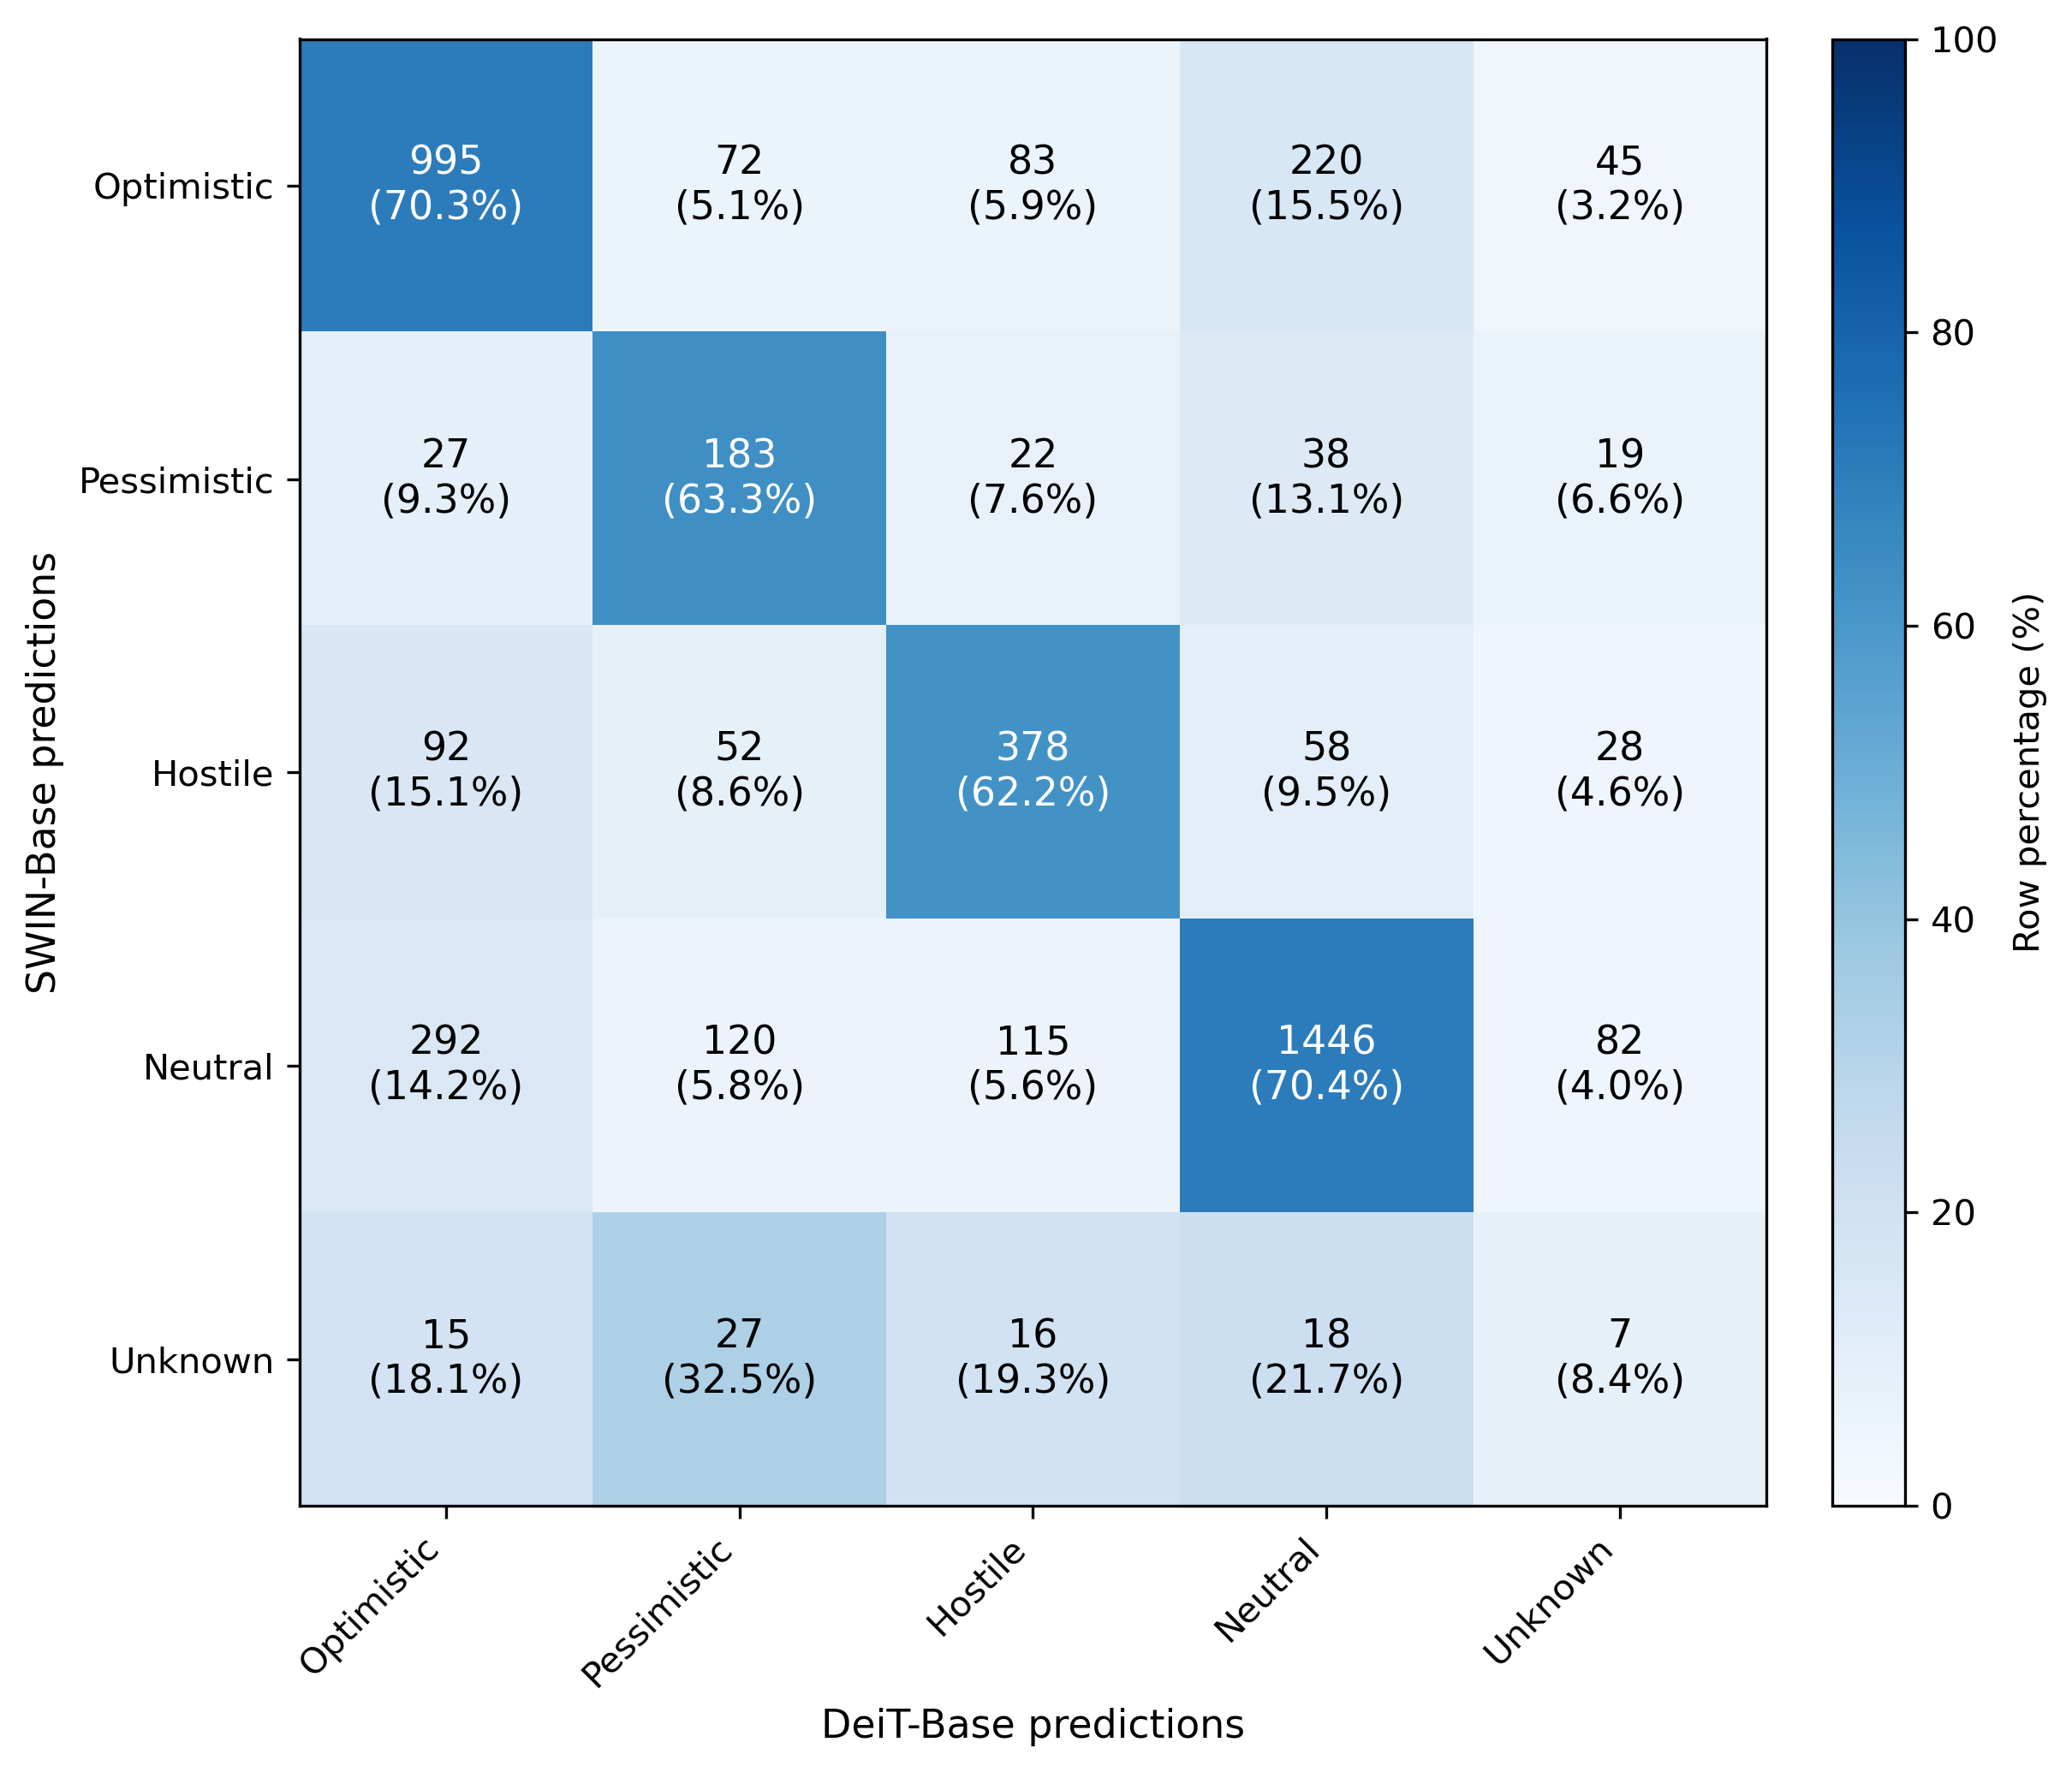

In [12]:
import matplotlib.pyplot as plt

#name classes for ordering
classes = ["Optimistic", 
           "Pessimistic", 
           "Hostile", 
           "Neutral", 
           "Unknown"]

#redefine table from above
cm = table
cm = cm.reindex(index = classes, columns = classes, fill_value = 0)

#normalized percentages row-wise
cm_pct = cm.div(cm.sum(axis = 1), axis = 0) * 100

#plot
fig, ax = plt.subplots(figsize = (8, 7), dpi = 300)
im = ax.imshow(cm_pct.values, cmap = "Blues", vmin = 0, vmax = 100)

#axis
ax.set_xticks(range(len(classes)))
ax.set_yticks(range(len(classes)))
ax.set_xticklabels(classes, rotation = 45, ha = "right")
ax.set_yticklabels(classes)

ax.set_xlabel("DeiT-Base predictions", fontsize = 11)
ax.set_ylabel("SWIN-Base predictions", fontsize = 11)

# Annotate each cell with count + percentage
threshold = 50  # because percentages range from 0–100

for i in range(len(classes)):
    for j in range(len(classes)):
        count = cm.iloc[i, j]
        pct = cm_pct.iloc[i, j]

        text = f"{count}\n({pct:.1f}%)"

        ax.text(j, i, text,
                ha = "center", va = "center",
                fontsize = 11,
                color = "white" if pct > threshold else "black")

#color bar
cbar = fig.colorbar(im, ax = ax, fraction = 0.046, pad = 0.04)
cbar.set_label("Row percentage (%)", fontsize = 10)

plt.tight_layout()

#save plot to mass storage
plt.savefig("/home/simon/Documents/Zwischen Wörtern und Pixeln/confusion_matrix_analysis.svg", bbox_inches = "tight")

plt.show()